In [65]:
import nltk
from nltk.stem import SnowballStemmer, WordNetLemmatizer, PorterStemmer
from nltk.corpus import stopwords
import spacy
from tqdm.auto import tqdm
tqdm.pandas()

import statsmodels.formula.api as smf
import pandas as pd

from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

import matplotlib.pyplot as plt

In [ ]:
data_file = Path('csv_files/UK_monarch_speeches.csv')
if not data_file.exists():
    raise FileNotFoundError(f"Could not find {data_file}. Run this notebook from the project folder.")

royal_corpus_data = pd.read_csv(data_file, encoding='utf-8', encoding_errors='ignore', index_col=0)

In [32]:
royal_raw = pd.read_csv(data_file, encoding='utf-8', encoding_errors='ignore', index_col=0)

In [15]:
royal_corpus_data.head()

,year,monarch,title,speech,url
date,,,,,
1952-12-25,1952,Queen Elizabeth II,Christmas Broadcast 1952,"Each Christmas, at this time, my beloved fathe...",https://www.royal.uk/queens-first-christmas-br...
1953-06-02,1953,Queen Elizabeth II,"A speech by The Queen on her Coronation Day, 1953","When I spoke to you last, at Christmas, I aske...",https://www.royal.uk/coronation-day-speech-2-j...
1953-06-02,1953,Queen Elizabeth II,"The Queen's Coronation Oath, 1953","In the Coronation ceremony of 2 June 1953, one...",https://www.royal.uk/coronation-oath-2-june-1953
1953-12-25,1953,Queen Elizabeth II,Christmas Broadcast 1953,Last Christmas I spoke to you from England; th...,https://www.royal.uk/christmas-broadcast-1953
1954-12-25,1954,Queen Elizabeth II,Christmas Broadcast 1954,It is now two years since my husband and I spe...,https://www.royal.uk/christmas-broadcast-1954


In [11]:
data_file = 'csv_files/hansard.csv'
parliamentary_corpus_data = pd.read_csv(data_file, encoding='utf-8')

parliamentary_corpus_data = parliamentary_corpus_data.dropna(subset='speaker')
parliamentary_corpus_data.drop(columns=["file","speech_id","type","speaker_id", "colnum","time","url"], 
                 inplace=True)

parliamentary_corpus_data.info()
parliamentary_corpus_data.head()

C:\Users\berti\AppData\Local\Temp\ipykernel_28764\3979010228.py:2: DtypeWarning: Columns (0: type, 1: speaker_id, 2: colnum, 3: url) have mixed types. Specify dtype option on import or set low_memory=False.
  parliamentary_corpus_data = pd.read_csv(data_file, encoding='utf-8')


<class 'pandas.DataFrame'>
Index: 4328210 entries, 5 to 4671401
Data columns (total 5 columns):
 #   Column      Dtype
---  ------      -----
 0   date        str  
 1   speaker     str  
 2   section     str  
 3   text        str  
 4   word_count  int64
dtypes: int64(1), str(4)
memory usage: 198.1 MB


,date,speaker,section,text,word_count
5,1952-01-29,Mr. Stephen Swingler,Re-armament and Essential Industries,asked the Minister of Labour whether he will m...,20
6,1952-01-29,Mr. Norman Dodds,Re-armament and Essential Industries,asked the Minister of Labour what proposals he...,26
7,1952-01-29,The Minister of Labour (Sir Walter Monckton),Re-armament and Essential Industries,I would ask the hon. Members to await the stat...,34
8,1952-01-29,Mr. Swingler,Re-armament and Essential Industries,asked the Minister of Labour what numbers of p...,28
9,1952-01-29,Sir W. Monckton,Re-armament and Essential Industries,I regret that it is not practicable to make su...,12


In [ ]:
parliamentary_corpus_data['date'] = pd.to_datetime(parliamentary_corpus_data['date'])
parliamentary_corpus_data['date'].dt.year.value_counts().sort_index()

date
1952    70837
1953    58475
1954    54596
1955    47620
1956    61463
        ...  
2021    53110
2022    60173
2023    53248
2024    53082
2025    73207
Name: count, Length: 74, dtype: int64

In [20]:
with pd.option_context('display.max_rows', None):
    print(royal_corpus_data['year'].value_counts().sort_index())

year
1952     1
1953     3
1954     1
1955     1
1956     1
1957     2
1958     1
1959     1
1960     1
1961     1
1962     1
1963     1
1964     1
1965     1
1966     1
1967     1
1968     1
1969     1
1970     2
1971     1
1972     1
1973     1
1974     1
1975     1
1976     1
1977     2
1978     1
1979     1
1980     1
1981     1
1982     1
1983     1
1984     1
1985     1
1986     1
1987     2
1988     2
1989     1
1990     1
1991     1
1992     2
1993     1
1994     1
1995     1
1996     1
1997     3
1998     1
1999     1
2000     1
2001     1
2002    30
2003    10
2004    17
2005    20
2006    16
2007    14
2008    13
2009    14
2010    12
2011    13
2012    15
2013     8
2014     7
2015    11
2016    13
2017    13
2018    14
2019     9
2020    11
2021    17
2022    11
2023    29
2024    25
2025    28
2026     4
Name: count, dtype: int64


We should only use royal data for 2002 onwards as every year just has 1 or 2 speeches per year. 

In [ ]:
royal_corpus_data = royal_corpus_data[royal_corpus_data['year'] >= 2002]
royal_corpus_data = royal_corpus_data.rename(columns ={'speech': 'text'})
parliamentary_corpus_data = parliamentary_corpus_data[parliamentary_corpus_data['date'].dt.year >= 2002]

In [24]:
with pd.option_context('display.max_rows', None):
    print(royal_corpus_data['year'].value_counts().sort_index())

with pd.option_context('display.max_rows', None):
    print(parliamentary_corpus_data['date'].dt.year.value_counts().sort_index())

year
2002    30
2003    10
2004    17
2005    20
2006    16
2007    14
2008    13
2009    14
2010    12
2011    13
2012    15
2013     8
2014     7
2015    11
2016    13
2017    13
2018    14
2019     9
2020    11
2021    17
2022    11
2023    29
2024    25
2025    28
2026     4
Name: count, dtype: int64
date
1952    70837
1953    58475
1954    54596
1955    47620
1956    61463
1957    54893
1958    49788
1959    51798
1960    54411
1961    65338
1962    53624
1963    49664
1964    55384
1965    64272
1966    57411
1967    70684
1968    70146
1969    67972
1970    45596
1971    60267
1972    67372
1973    54756
1974    43273
1975    57709
1976    67284
1977    57599
1978    58642
1979    47741
1980    62903
1981    53187
1982    58020
1983    48337
1984    61677
1985    62630
1986    63645
1987    52715
1988    65515
1989    65429
1990    65277
1991    56644
1992    45831
1993    58213
1994    52740
1995    52383
1996    54199
1997    42833
1998    61055
1999    54495
2000    57378
200

Preprocessing Steps:


In [ ]:
def download_nltk_resources():
    required_resources = ['wordnet', 'stopwords', 'punkt', 'punkt_tab']
    for resource in required_resources:
        try:
            nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
        except LookupError:
            nltk.download(resource)

download_nltk_resources()

try:
    sp = spacy.load('en_core_web_sm')
except OSError:
    from spacy.cli import download as spacy_download

    print("Installing spaCy model 'en_core_web_sm' for this environment...")
    spacy_download('en_core_web_sm')
    sp = spacy.load('en_core_web_sm')

tqdm.pandas()

porter = SnowballStemmer("english")
lmtzr = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))


"""
This module provides helper functions for text preprocessing. 
Each function applies punctuation removal and stopword removal, and then one of three options:
    0: Lowercasing only.
    1: Lowercasing plus stemming.
    2: Lemmatizing (using spaCy; original casing is preserved).

The functions return a string of tokens separated by spaces.
"""

def preprocess_lower(text):
    """
    Preprocess text by:
       - Converting to lowercase.
       - Removing punctuation.
       - Tokenizing.
       - Removing stopwords.
    
    Returns:
        str: A string of filtered tokens separated by spaces.
    """
    text_lower = text.lower()
    text_no_punct = re.sub(r'[^\w\s]', '', text_lower)
    tokens = word_tokenize(text_no_punct)
    filtered_tokens = [token for token in tokens if token not in STOP_WORDS]
    return " ".join(filtered_tokens)

def preprocess_stem(text):
    """
    Preprocess text by performing all steps in preprocess_lower() and then applying stemming.
    
    Returns:
        str: A string of stemmed tokens separated by spaces.
    """
    tokens = preprocess_lower(text).split()
    ps = PorterStemmer()
    stemmed_tokens = [ps.stem(token) for token in tokens]
    return " ".join(stemmed_tokens)

def preprocess_lemma(text):
    """
    Preprocess text by:
       - Removing punctuation and stopwords using spaCy's token attributes.
       - Lemmatizing the text.
       - (Note: This function does NOT lowercase the text.)
    
    Returns:
        str: A string of lemmatized tokens separated by spaces.
    """
    doc = sp(text)
    lemmatized_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.lemma_.strip() != '']
    return " ".join(lemmatized_tokens)

def tokenize(text, mode=0):
    """
    General tokenize function. Always applies punctuation and stopword removal and then:
    
      mode = 0: Applies lowercasing.
      mode = 1: Applies lowercasing and stemming.
      mode = 2: Applies lemmatization (without lowercasing the original text).
    
    Args:
        text (str): The input text to be processed.
        mode (int): Processing mode (0 for lowercasing; 1 for stemming; 2 for lemmatizing).

    Returns:
        str: A string of processed tokens separated by spaces.

    Raises:
        ValueError: If an invalid mode is provided.
    """
    if mode == 0:
        return preprocess_lower(text)
    elif mode == 1:
        return preprocess_stem(text)
    elif mode == 2:
        return preprocess_lemma(text)
    else:
        raise ValueError("Invalid mode. Please use 0 for lowercasing, 1 for stemming, or 2 for lemmatizing.")


In [44]:
parliamentary_corpus_data['text_clean'] = parliamentary_corpus_data['text'].astype(str).progress_apply(lambda x: tokenize(x, mode=2))

royal_corpus_data['text_clean'] = royal_corpus_data['text'].astype(str).progress_apply(lambda x: tokenize(x, mode=2))

100%|██████████| 374/374 [00:21<00:00, 17.24it/s]


In [46]:
parliamentary_corpus_data.to_csv(r'D:\parliamentary_preprocessed.csv', index=False)
royal_corpus_data.to_csv(r'D:\royal_preprocessed.csv', index=False)

In [5]:
parliamentary_corpus_data = pd.read_csv(r'D:\parliamentary_preprocessed.csv')
royal_corpus_data = pd.read_csv(r'D:\royal_preprocessed.csv')

In [22]:
parliamentary_corpus_data = parliamentary_corpus_data[parliamentary_corpus_data['word_count'] >= 20]
royal_corpus_data = royal_corpus_data.reset_index()

parliamentary_corpus_data = parliamentary_corpus_data[parliamentary_corpus_data['date'].dt.year >= 2002]

In [42]:
royal_raw['date'] = pd.to_datetime(royal_raw['date'])

royal_raw = royal_raw[royal_raw['year'] >= 2002]
royal_raw = royal_raw.rename(columns ={'speech': 'text'})

royal_corpus_data['date'] = royal_raw['date'].values
royal_corpus_data['quarter'] = royal_corpus_data['date'].dt.to_period('Q')

print(royal_corpus_data[['date', 'quarter']].head())

        date quarter
0 2002-02-19  2002Q1
1 2002-02-25  2002Q1
2 2002-02-25  2002Q1
3 2002-02-27  2002Q1
4 2002-03-02  2002Q1


In [23]:
royal_corpus_data
parliamentary_corpus_data

,date,speaker,section,text,word_count,text_clean,quarter
2859948,2002-01-08,Jack Straw,Middle East Peace Process,Her Majesty's Government are fully engaged wit...,101,Majesty Government fully engage United States ...,2002Q1
2859949,2002-01-08,James Clappison,Middle East Peace Process,What is the Foreign Secretary's response to th...,105,Foreign Secretary response letter receive Shim...,2002Q1
2859950,2002-01-08,Jack Straw,Middle East Peace Process,I congratulate the hon. Gentleman on the ingen...,154,congratulate hon gentleman ingenuity question ...,2002Q1
2859951,2002-01-08,Helen Jackson,Middle East Peace Process,What possible justification was there for tryi...,62,possible justification try prevent leader Pale...,2002Q1
2859952,2002-01-08,Jack Straw,Middle East Peace Process,We did not think that this restriction was jus...,37,think restriction justify position closure lif...,2002Q1
...,...,...,...,...,...,...,...
4328205,2025-12-18,Dave Robertson,Indices of Deprivation: England,I thank my hon. Friend for bringing the storie...,75,thank hon friend bring story real life debate ...,2025Q4
4328206,2025-12-18,Chris Webb,Indices of Deprivation: England,I thank my hon. Friend for his kind words; I t...,1432,thank hon friend kind word think know party Ho...,2025Q4
4328207,2025-12-18,Nusrat Ghani,Indices of Deprivation: England,"I second that. I call the Minister, whom it is...",21,second Minister good write new Christmas card,2025Q4
4328208,2025-12-18,Miatta Fahnbulleh,Indices of Deprivation: England,I am grateful to my hon. Friend Coastal commu...,1198,grateful hon friend coastal community Blackpoo...,2025Q4


In [43]:
parliamentary_corpus_data['date'] = pd.to_datetime(parliamentary_corpus_data['date'])
royal_corpus_data['date'] = pd.to_datetime(royal_corpus_data['date']) 

parliamentary_corpus_data['quarter'] = parliamentary_corpus_data['date'].dt.to_period('Q')
royal_corpus_data['quarter'] = royal_corpus_data['date'].dt.to_period('Q')

parl_quarterly = (
    parliamentary_corpus_data
    .groupby('quarter')['text_clean']
    .apply(lambda x: ' '.join(x.dropna()))
    .reset_index()
)

royal_quarterly = (
    royal_corpus_data
    .groupby('quarter')['text_clean']
    .apply(lambda x: ' '.join(x.dropna()))
    .reset_index()
)

quarterly = parl_quarterly.merge(
    royal_quarterly,
    on='quarter',
    suffixes=('_parl', '_royal')
)

print(royal_quarterly['quarter'].head())

0    2002Q1
1    2002Q2
2    2002Q3
3    2002Q4
4    2003Q2
Name: quarter, dtype: period[Q-DEC]


In [44]:
print(type(parl_quarterly['quarter'].iloc[0]))
print(type(royal_quarterly['quarter'].iloc[0]))

print(parl_quarterly['quarter'].head())
print(royal_quarterly['quarter'].head())

<class 'pandas.Period'>
<class 'pandas.Period'>
0    2002Q1
1    2002Q2
2    2002Q3
3    2002Q4
4    2003Q1
Name: quarter, dtype: period[Q-DEC]
0    2002Q1
1    2002Q2
2    2002Q3
3    2002Q4
4    2003Q2
Name: quarter, dtype: period[Q-DEC]


In [ ]:
print(quarterly['quarter'].min(), "to", quarterly['quarter'].max())
print(f"Total quarters: {len(quarterly)}")

2002Q1 to 2025Q4
Total quarters: 92


In [47]:
royal_corpus_data

,level_0,index,year,monarch,title,text,url,text_clean,date,quarter
0,0,0,2002,Queen Elizabeth II,"Jamaican Parliament, 19 February 2002","Madam President, Madam Speaker:\n\nI thank you...",https://www.royal.uk/jamaican-parliament-19-fe...,Madam President Madam Speaker thank behalf Pri...,2002-02-19,2002Q1
1,1,1,2002,Queen Elizabeth II,"Maori gathering at Rehua Marae, Christchurch, ...","E te iwi, Ngai Tahu, tena koutou katoa (To the...",https://www.royal.uk/maori-gathering-rehua-mar...,e te iwi Ngai Tahu tena koutou katoa people Ng...,2002-02-25,2002Q1
2,2,2,2002,Queen Elizabeth II,"State dinner in Wellington, New Zealand, 25 Fe...",Tena koutou katoa.(Please accept my greetings....,https://www.royal.uk/state-dinner-wellington-n...,tena koutou katoa.(please accept greeting than...,2002-02-25,2002Q1
3,3,3,2002,Queen Elizabeth II,"Adelaide Festival Hall, Australia, 27 February...","Prime Minister, Premier, Mr. Crean, Mr. Rann, ...",https://www.royal.uk/adelaide-festival-hall-au...,Prime Minister Premier Mr. Crean Mr. Rann Ladi...,2002-02-27,2002Q1
4,4,4,2002,Queen Elizabeth II,Opening of the Commonwealth Heads of Governmen...,"Mr Prime Minister, Mr Secretary General, Presi...",https://www.royal.uk/opening-commonwealth-head...,Mr Prime Minister Mr Secretary General Preside...,2002-03-02,2002Q1
...,...,...,...,...,...,...,...,...,...,...
369,369,369,2025,King Charles III,A speech by His Majesty The King at the Lord H...,"Ladies and gentlemen, I am delighted to be abl...",https://www.royal.uk/news-and-activity/2025-12...,lady gentleman delighted able join today Brita...,2025-12-19,2025Q4
370,370,370,2026,King Charles III,"A message from The King, following the attack ...",My wife and I were profoundly shocked and sadd...,https://www.royal.uk/news-and-activity/2026-02...,wife profoundly shock sadden learn dreadful at...,2026-02-11,2026Q1
371,371,371,2026,King Charles III,A message from The King ahead of a reception a...,So to those who provide care - whether you wea...,https://www.royal.uk/news-and-activity/2026-02...,provide care wear uniform simply clothe feel a...,2026-02-12,2026Q1
372,372,372,2026,King Charles III,A message from The King on the death of Revere...,My wife and I were deeply saddened to hear of ...,https://www.royal.uk/news-and-activity/2026-02...,wife deeply sadden hear thedeathofthereverend ...,2026-02-18,2026Q1


In [49]:
royal_quarterly

,quarter,text_clean
0,2002Q1,Madam President Madam Speaker thank behalf Pri...
1,2002Q2,beloved mother die week ago deeply move outpou...
2,2002Q3,give great pleasure open Millennium Point toda...
3,2002Q4,Excellencies Prime Minister honourable member ...
4,2003Q2,Colonel Massey Officers Warrant Officers Non c...
...,...,...
88,2025Q1,Queen want extend heartfelt congratulation Gla...
89,2025Q2,Published09 April 2025 move think great great ...
90,2025Q3,today mark year tragic event 7th July 2005 hea...
91,2025Q4,today wonderful way celebrate Lord bounty year...


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range = (1,1), min_df = 0.01, max_df = 0.85, max_features = 10000)

tfidf.fit(royal_quarterly['text_clean'])

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [51]:
royal_matrix = tfidf.transform(royal_quarterly['text_clean'])
feature_names = tfidf.get_feature_names_out()

In [52]:
N_Terms = 25

def get_top_terms(tfidf_row, feature_names, n = N_Terms):
    scores = tfidf_row.toarray().flatten()
    top_indices = scores.argsort()[::-1][:n]
    return [(feature_names[i], scores[i]) for i in top_indices if scores [i] > 0]

royal_quarterly['top_terms'] = [get_top_terms(royal_matrix[i], feature_names) for i in range(royal_matrix.shape[0])]

In [58]:
def get_background_quarter(parl_df, current_quarter, top_k=200):
    prev_quarter = current_quarter - 1
    prev_text = parl_df[parl_df['quarter'] == prev_quarter]['text_clean']
    if len(prev_text) == 0:
        return set()
    cv = CountVectorizer(max_features=top_k)
    cv.fit(prev_text)
    return set(cv.get_feature_names_out())

def filter_vocab(top_terms, background_terms):
    return [(term, score) for term, score in top_terms 
            if term not in background_terms]

royal_quarterly['vocab_filtered'] = royal_quarterly.apply(
    lambda row: filter_vocab(
        row['top_terms'],
        get_background_quarter(parl_quarterly, row['quarter'])
    ),
    axis=1
)

royal_quarterly['n_terms_after_filter'] = royal_quarterly['vocab_filtered'].apply(len)
print(royal_quarterly['n_terms_after_filter'].describe())

count    93.000000
mean     21.946237
std       2.360755
min      14.000000
25%      21.000000
50%      22.000000
75%      24.000000
max      25.000000
Name: n_terms_after_filter, dtype: float64


In [61]:
WINDOW = 14

def compute_uptake(debate_day, vocab_set):
    #to see the share of words o a given day, that belong to the V(s) set

    if len(debate_day) == 0:
        return None
    all_words = ''.join(debate_day).split()
    if len(all_words) == 0:
        return None
    matches = sum(1 for w in all_words if w in vocab_set)
    return matches / len(all_words)

records = []

for _, row in royal_quarterly.iterrows():
    vocab_set = set(term for term, score in row['vocab_filtered'])
    if len(vocab_set) == 0:
        continue

    current_quarter = row['quarter']
    
    for offset in [-2, -1, 1, 2]:
        target_q = current_quarter + offset
        parl_row = parl_quarterly[parl_quarterly['quarter'] == target_q]
        if len(parl_row) == 0:
            continue
        uptake = compute_uptake(parl_row.iloc[0]['text_clean'], vocab_set)
        if uptake is not None:
            records.append({
                'royal_quarter': current_quarter,
                'parl_quarter': target_q,
                'offset': offset,     
                'post': int(offset > 0),
                'uptake': uptake
            })

panel_df = pd.DataFrame(records)

In [62]:
panel_df.to_csv('panel_df.csv', index=False)
print(panel_df.shape)
print(panel_df.head())

(364, 5)
  royal_quarter parl_quarter  offset  post    uptake
0        2002Q1       2002Q2       1     1  0.013732
1        2002Q1       2002Q3       2     1  0.011475
2        2002Q2       2002Q1      -1     0  0.001412
3        2002Q2       2002Q3       1     1  0.001525
4        2002Q2       2002Q4       2     1  0.002055


In [64]:
panel_df['royal_quarter'] = panel_df['royal_quarter'].astype(str)

model = smf.ols(
    'uptake ~ post + offset + C(royal_quarter)',
    data=panel_df
)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 uptake   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     71.57
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          1.63e-148
Time:                        15:53:46   Log-Likelihood:                 2464.7
No. Observations:                 364   AIC:                            -4739.
Df Residuals:                     269   BIC:                            -4369.
Df Model:                          94                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

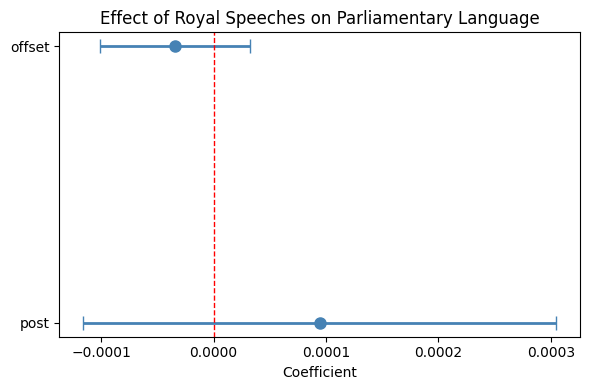

In [66]:
params = results.params[['post', 'offset']]
conf = results.conf_int().loc[['post', 'offset']]

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    x=params.values,
    y=params.index,
    xerr=[params.values - conf[0].values, conf[1].values - params.values],
    fmt='o', color='steelblue', capsize=5, linewidth=2, markersize=8
)

ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Coefficient')
ax.set_title('Effect of Royal Speeches on Parliamentary Language')
plt.tight_layout()
plt.show()

Post compares uptake in quarters after a royal speech vs quarters before it. A positive coefficient would mean parliamentary language picks up more royal vocab after the quarter tha before it.

Offset captures whether the uptake or decreases the further you move from the quarter. Negative coefficient means that uptakes fades.

However, this analysis suggests that there is no influence from the royal  speeches on the vocabulary used by the parliament.